# 03 — Programmatic scenarios

What happens to the TB epidemic if routine services change? Two levers are explored, both ramping in
from `scenario_start_time` (2026) over `scenario_ramp_years`:

* `future_detection_rate_rel` — the future passive case detection rate, relative to the current one;
* `future_tx_success_prop` — the future TB treatment success proportion.

Every scenario is run once, on the **same single parameter set**: the maximum likelihood estimate
saved by notebook 02 (or re-optimised here if that file is missing). Scenarios therefore differ only
through their parameter overrides, and the comparison is deterministic — no credible intervals are
reported.

Contents:

1. **Scenarios** — what is being compared.
2. **Run** — load the MLE parameters and run all scenarios once each.
3. **Trajectories** — burden and care cascade over time, by scenario.
4. **Impact** — TB episodes and deaths averted relative to the status quo.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

import tbtoy.plotting as pl
import tbtoy.runner_tools as rt
from tbtoy.config import DEFAULT_MODEL_CONFIG
from tbtoy.paths import MLE_PARAMS_PATH
from tbtoy.scenarios import PROGRAMMATIC_SCENARIOS, get_scenario_names

sc_names = get_scenario_names(PROGRAMMATIC_SCENARIOS)
end_year = DEFAULT_MODEL_CONFIG["end_time"]


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [3]:
pd.DataFrame(
    [
        {
            "scenario": scenario.sc_name,
            "parameter overrides": scenario.params_ow or "none (status quo)",
            "description": scenario.description,
        }
        for scenario in PROGRAMMATIC_SCENARIOS
    ],
    index=[scenario.sc_id for scenario in PROGRAMMATIC_SCENARIOS],
)


,scenario,parameter overrides,description
baseline,Status quo,none (status quo),Current passive case detection and treatment s...
detection_down,Detection -30%,{'future_detection_rate_rel': 0.7},Passive case detection rate declines by 30% (e...
detection_up,Detection +50%,{'future_detection_rate_rel': 1.5},Passive case detection rate improves by 50%.
detection_up_strong,Detection x2,{'future_detection_rate_rel': 2.0},Passive case detection rate doubles.
tsr_up,Treatment success 95%,{'future_tx_success_prop': 0.95},Treatment success proportion improves to 95%.
tsr_down,Treatment success 75%,{'future_tx_success_prop': 0.75},Treatment success proportion deteriorates to 75%.
detection_and_tsr_up,Detection x2 + TSR 95%,"{'future_detection_rate_rel': 2.0, 'future_tx_...",Combined improvement of passive detection and ...


## 2. Run the scenarios

One BCM is built per scenario, then every scenario is run once with the maximum likelihood parameter
set. `rt.get_mle_params` reuses `outputs/calibration/mle_params.yml` if notebook 02 has been run, and
otherwise re-runs the `nevergrad` optimisation (on the baseline scenario) and saves the result for
next time.


In [4]:
bcm_dict = rt.build_bcm_dict(PROGRAMMATIC_SCENARIOS)

print("Reusing MLE from notebook 02" if MLE_PARAMS_PATH.exists() else "No saved MLE found, optimising here")
mle_params = rt.get_mle_params(bcm_dict["baseline"], budget=1000)

scenario_outputs = rt.run_scenarios_single_params(bcm_dict, mle_params)

output_dir = rt.create_output_dir("programmatic_scenarios")
for sc_id, derived_outputs in scenario_outputs.items():
    derived_outputs.to_parquet(output_dir / f"derived_outputs_{sc_id}.parquet")

pd.Series(mle_params, name="MLE").to_frame()


Reusing MLE from notebook 02


,MLE
raw_transmission_rate,0.000164
rel_sus_contained,0.311570
rel_sus_cleared,0.800302
breakdown_rate,0.129307
clearance_rate,0.042659
clinical_progression_rate,3.292457
infectiousness_gain_rate,3.181586
recent_detection_rate,2.395737
passive_detection_inflection,1998.159305
passive_detection_past_frac,0.722627


## 3. Projected trajectories

One trajectory per scenario, all from the same parameter set. The scenarios are identical up to 2026
by construction, so only the projection period is shown.


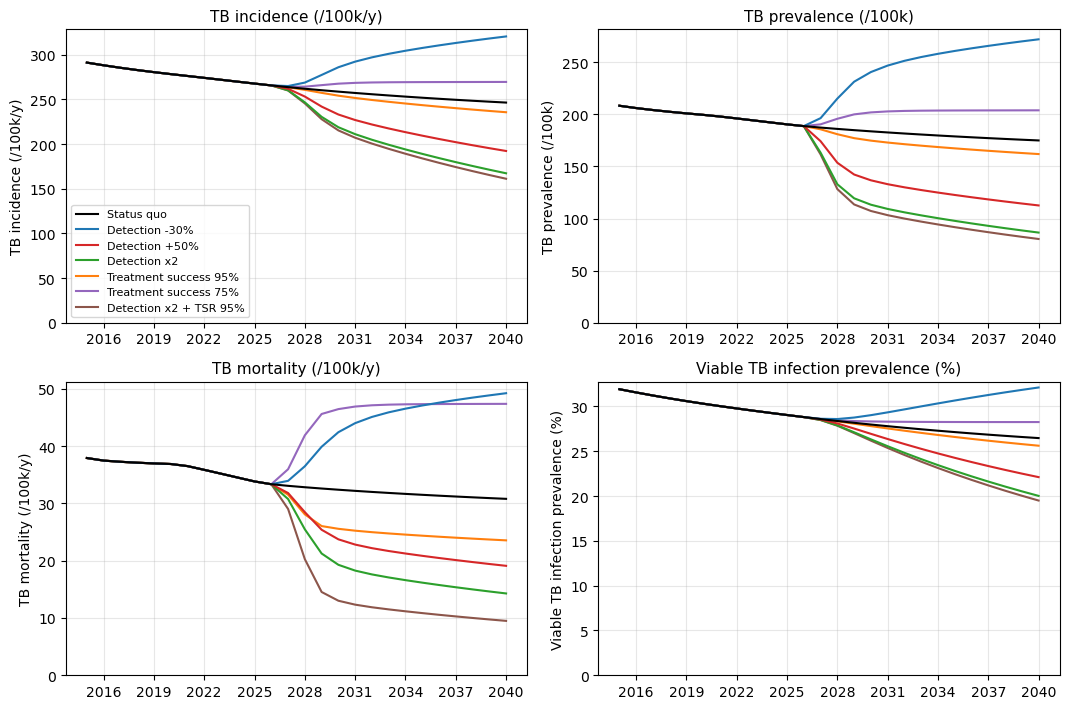

In [5]:
burden_outputs = ["tb_incidence_per100k", "tb_prevalence_per100k", "tb_mortality_per100k", "viable_tbi_prevalence_perc"]

pl.plot_scenarios_single_params(scenario_outputs, burden_outputs, sc_names, x_lim=(2015, end_year));


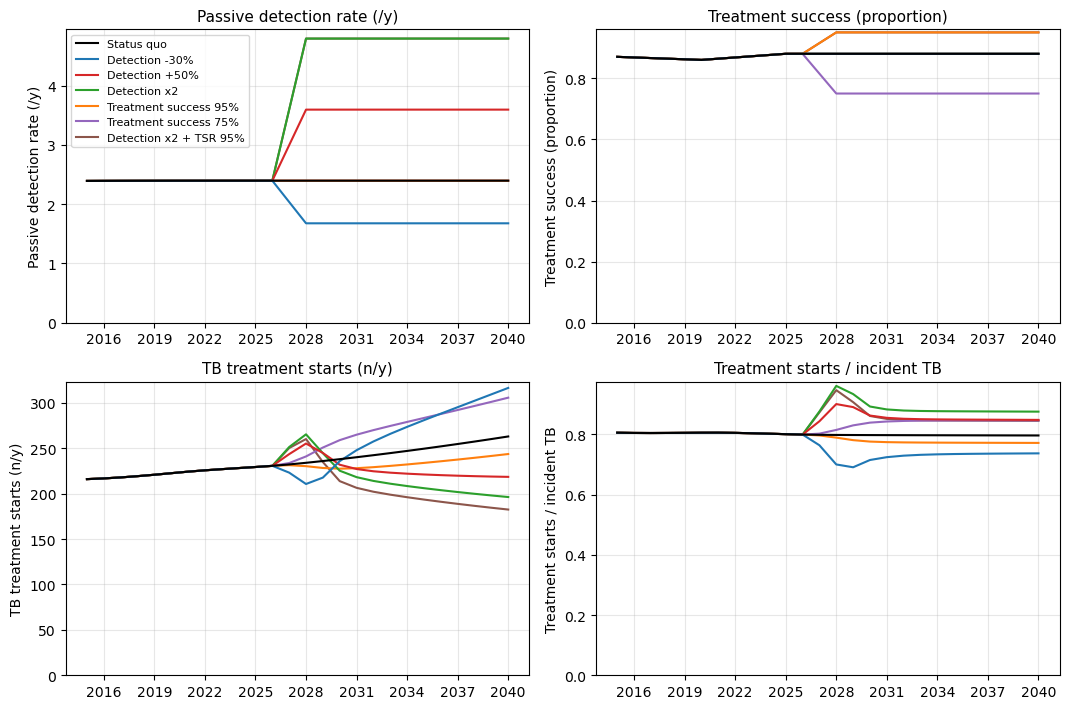

In [6]:
cascade_outputs = ["passive_detection_rate", "treatment_success_prop", "tb_treatment_starts", "case_detection_prop"]

pl.plot_scenarios_single_params(scenario_outputs, cascade_outputs, sc_names, x_lim=(2015, end_year));


In [7]:
summary_outputs = ["tb_incidence_per100k", "tb_prevalence_per100k", "tb_mortality_per100k", "tb_treatment_starts"]

pd.DataFrame(
    {
        pl.get_title(output): {
            sc_names[sc_id]: derived_outputs.loc[end_year, output]
            for sc_id, derived_outputs in scenario_outputs.items()
        }
        for output in summary_outputs
    }
).round(1).rename_axis(f"Value in {int(end_year)}")


,TB incidence (/100k/y),TB prevalence (/100k),TB mortality (/100k/y),TB treatment starts (n/y)
Value in 2040,,,,
Status quo,246.6,175.0,30.8,263.0
Detection -30%,320.6,272.1,49.2,316.4
Detection +50%,192.4,112.6,19.1,218.5
Detection x2,167.4,86.6,14.3,196.3
Treatment success 95%,235.7,161.9,23.5,243.6
Treatment success 75%,269.7,203.9,47.4,305.7
Detection x2 + TSR 95%,161.3,80.4,9.5,182.5


## 4. Impact relative to the status quo

Health gains are the difference between the baseline and each scenario in cumulative TB episodes and
TB deaths (accumulated from 2026), evaluated at the MLE. Negative values indicate a worse outcome
than the status quo.


In [8]:
diff_df = rt.calculate_diff_outputs_single_params(scenario_outputs, ref_sc="baseline", end_year=end_year)
diff_df.to_parquet(output_dir / "diff_outputs_df.parquet")

diff_df.rename(index=sc_names).round(3)


,TB_averted,TB_averted_relative,deaths_averted,deaths_averted_relative
scenario,,,,
Detection -30%,-775.548,-0.168,-221.840,-0.384
Detection +50%,607.689,0.132,158.675,0.275
Detection x2,907.255,0.196,231.862,0.401
Treatment success 95%,116.957,0.025,111.734,0.193
Treatment success 75%,-244.655,-0.053,-242.834,-0.420
Detection x2 + TSR 95%,980.659,0.212,320.606,0.555


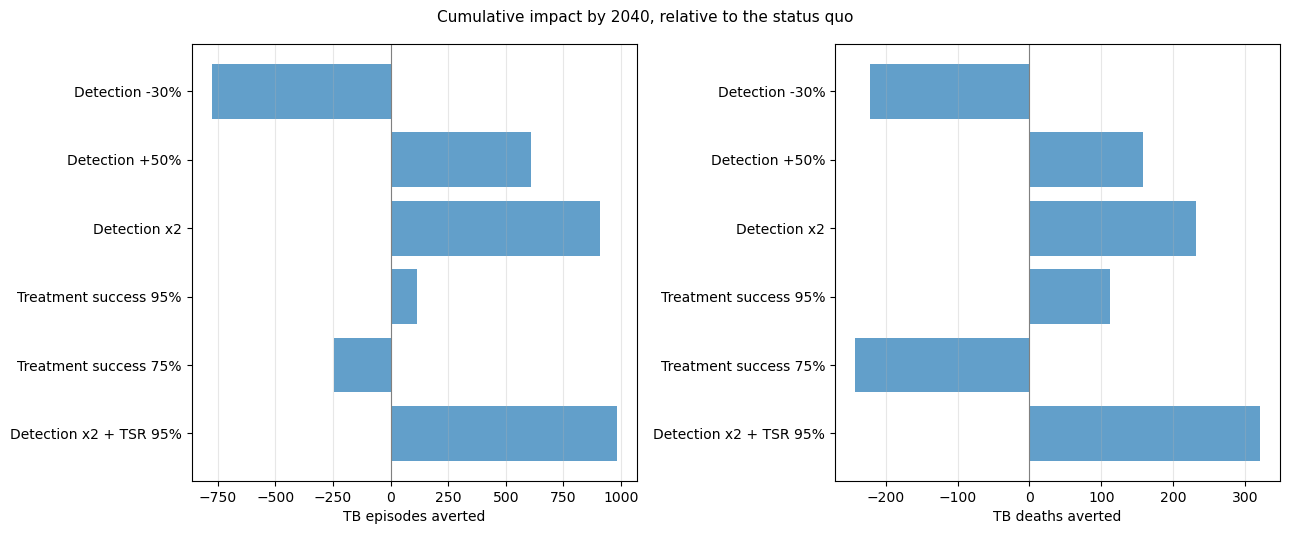

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 0.6 * len(diff_df) + 1.8))
for ax, output in zip(axes, ["TB_averted", "deaths_averted"]):
    pl.plot_diff_outputs_single_params(diff_df, output, sc_names, ax=ax)
    ax.axvline(0.0, color="grey", linewidth=0.8)
fig.suptitle(f"Cumulative impact by {int(end_year)}, relative to the status quo", fontsize=11)
fig.tight_layout()


In [10]:
cumulative_outputs = ["cum_tb_incidence", "cum_tb_mortality", "cum_tb_treatment_starts"]
cumulative_df = rt.calculate_cumulative_outputs_single_params(
    scenario_outputs, outputs=cumulative_outputs, end_year=end_year
)
cumulative_df.to_parquet(output_dir / "cumulative_outputs_df.parquet")

cumulative_df.rename(index=sc_names).round(0)


,cum_tb_incidence,cum_tb_mortality,cum_tb_treatment_starts
scenario,,,
Status quo,4619.0,578.0,3682.0
Detection -30%,5395.0,799.0,3955.0
Detection +50%,4011.0,419.0,3421.0
Detection x2,3712.0,346.0,3274.0
Treatment success 95%,4502.0,466.0,3500.0
Treatment success 75%,4864.0,820.0,4070.0
Detection x2 + TSR 95%,3638.0,257.0,3120.0


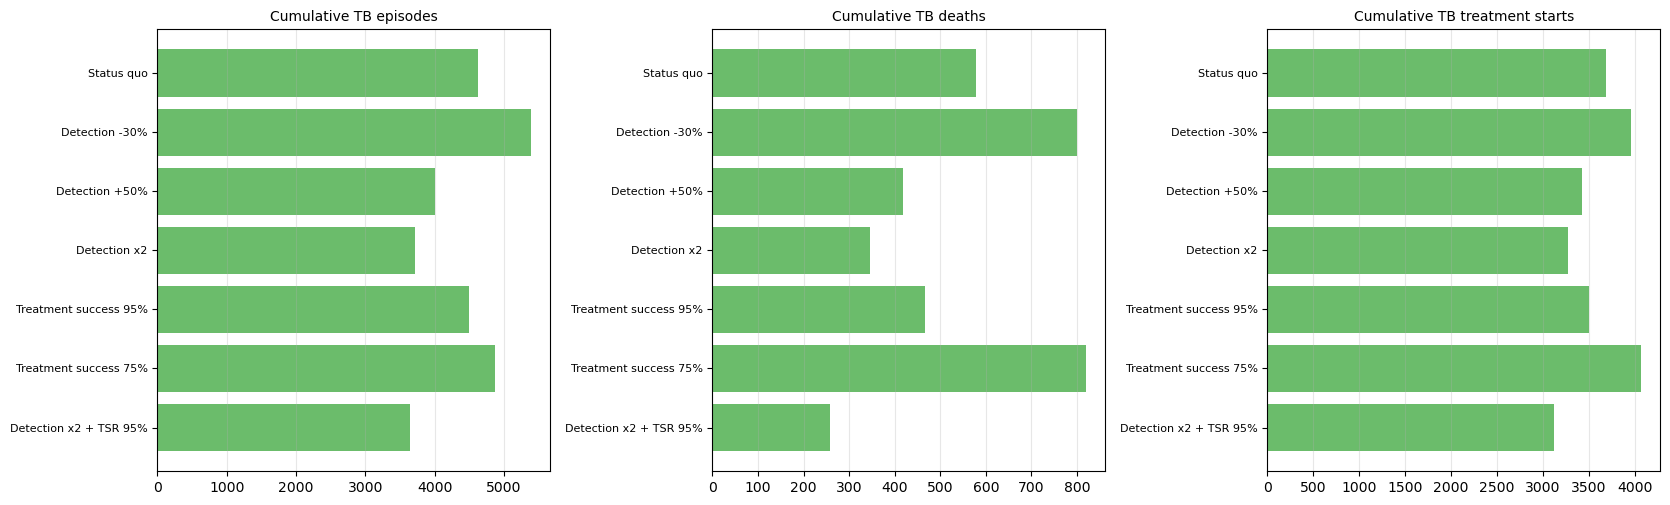

In [11]:
pl.plot_cumulative_outputs_single_params(cumulative_df, cumulative_outputs, sc_names, n_col=3);
